<a href="https://colab.research.google.com/github/nowshine-sharmili-piuli/Cyber_Attack_Detection_Using_Machine_Learning_on_the_UNSW_NB15_Dataset/blob/main/Cyber_Attack_Detection_Using_Machine_Learning_on_the_UNSW_NB15_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install XGboost

In [2]:
!pip install xgboost

Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

Load Dataset

In [4]:
train= pd.read_csv("/content/drive/MyDrive/Computer Security Project/UNSW_NB15/UNSW_NB15_training-set.csv")
test= pd.read_csv("/content/drive/MyDrive/Computer Security Project/UNSW_NB15/UNSW_NB15_testing-set.csv")

df=pd.concat([train,test],ignore_index=True)
print(df.shape)
df.head()


(257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Data Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  si

EDA

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 257673
Columns: 45


In [7]:
df.dtypes.value_counts()

,count
int64,30
float64,11
object,4


In [8]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274,0.639077
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618,0.480269
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000,1.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,257673.0,7.281182e+04,4.892992e+04,1.0,32210.000000,64419.000000,1.109230e+05,1.753410e+05
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09


Missing Values

In [10]:
df.isnull().sum()

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


Attack Categories

In [11]:
df["attack_cat"].value_counts()

,count
attack_cat,
Normal,93000
Generic,58871
Exploits,44525
Fuzzers,24246
DoS,16353
Reconnaissance,13987
Analysis,2677
Backdoor,2329
Shellcode,1511


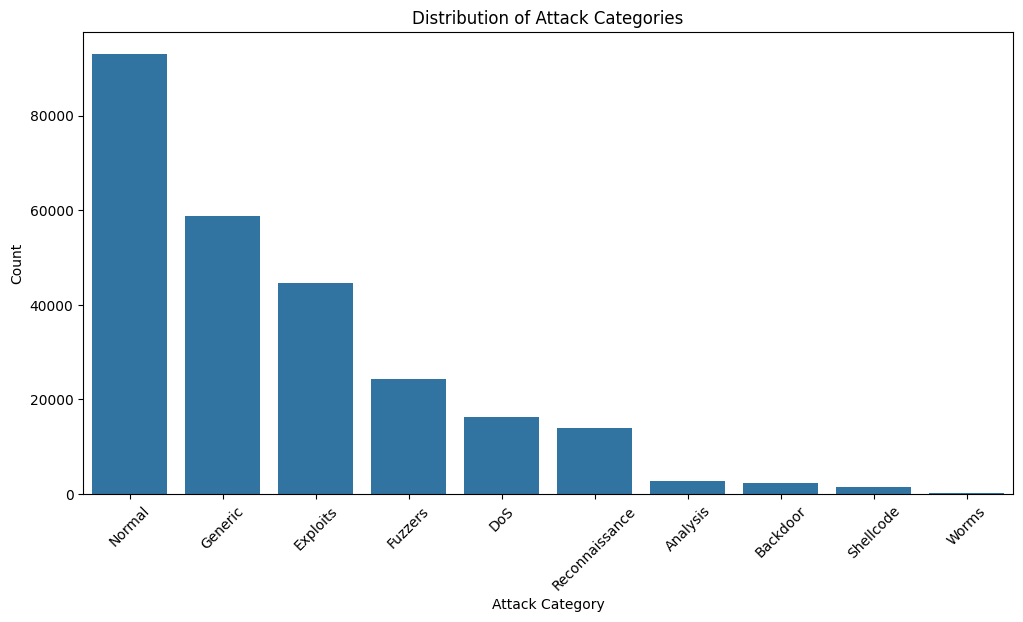

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="attack_cat", order=df["attack_cat"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Attack Categories")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.show()

Plot

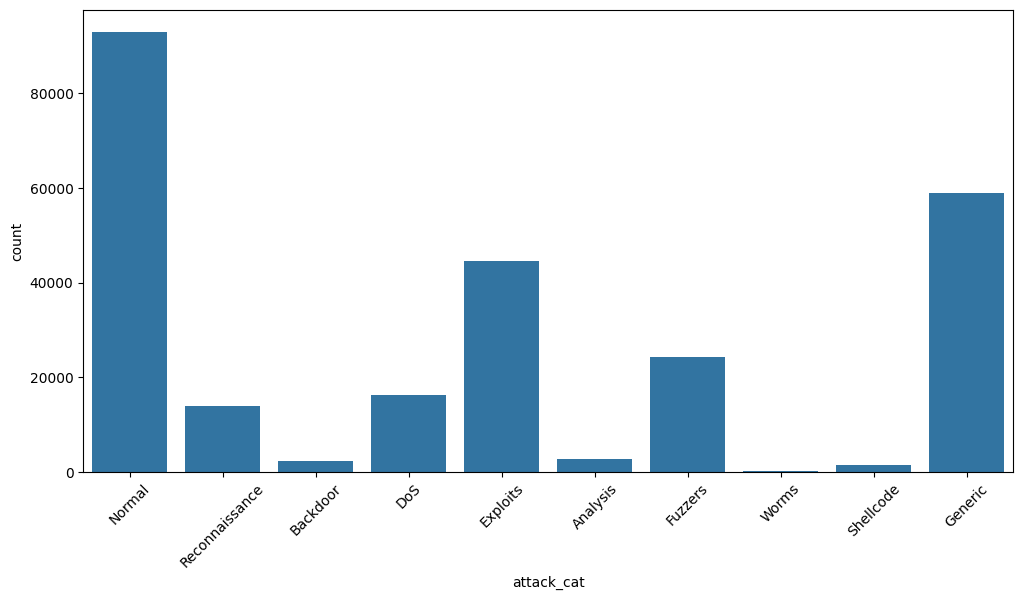

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="attack_cat")
plt.xticks(rotation=45)
plt.show()

Correlation Heatmap

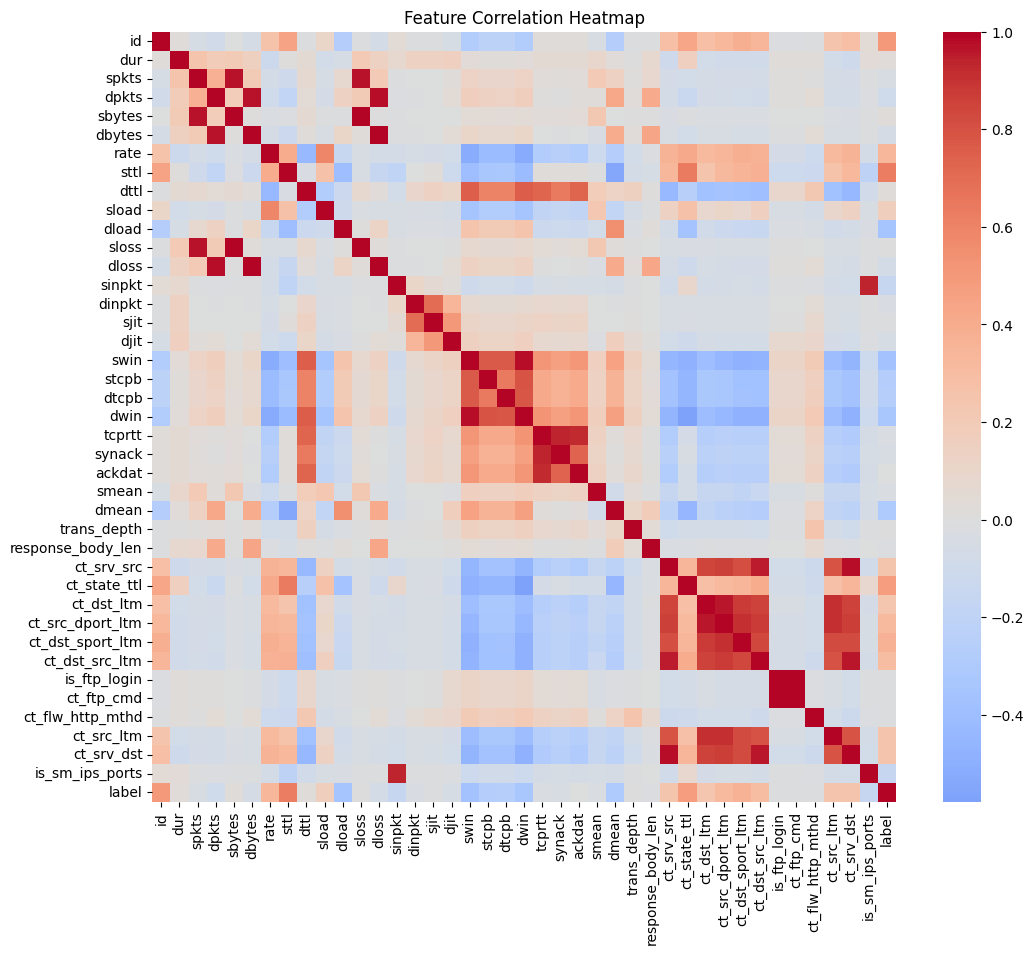

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

Histogram of Important Numeric Features

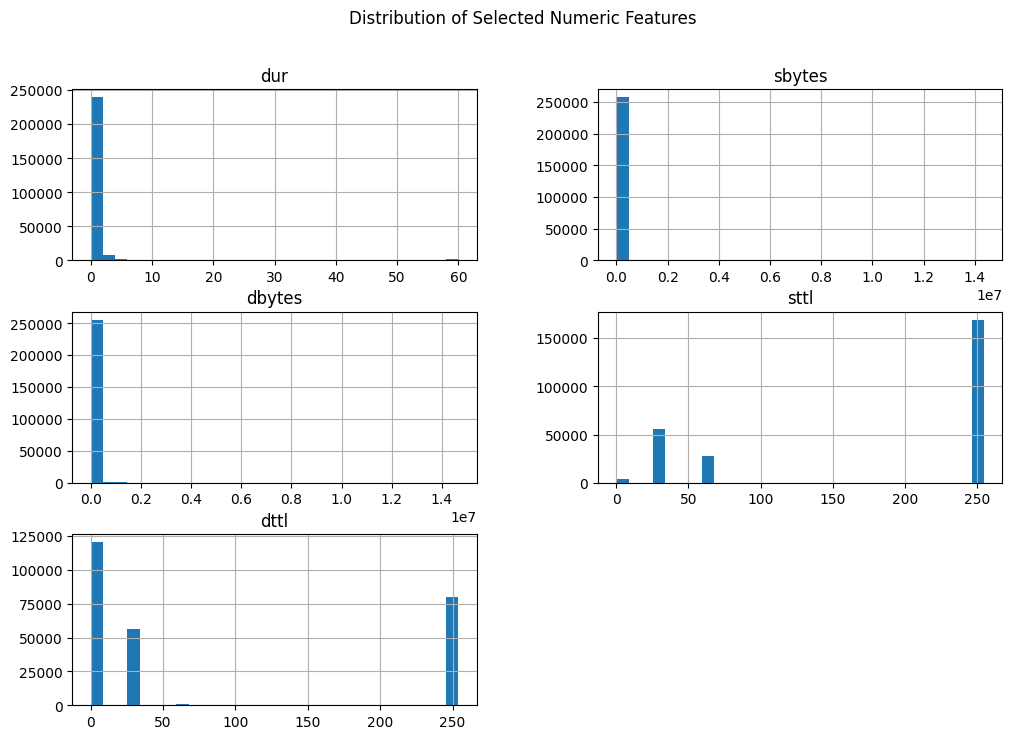

In [15]:
features = ["dur", "sbytes", "dbytes", "sttl", "dttl"]

df[features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Selected Numeric Features")
plt.show()

Boxplot for Outlier Detection--Network traffic features-এ outlier আছে কিনা দেখা যাবে।

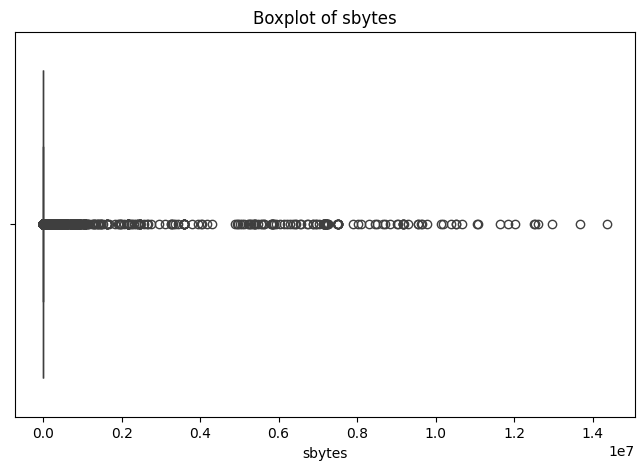

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["sbytes"])
plt.title("Boxplot of sbytes")
plt.show()

Pairplot (Small Sample)

Dataset অনেক বড়, তাই sample নিয়ে pairplot

Different attack class feature space-এ আলাদা cluster তৈরি করছে কিনা দেখা


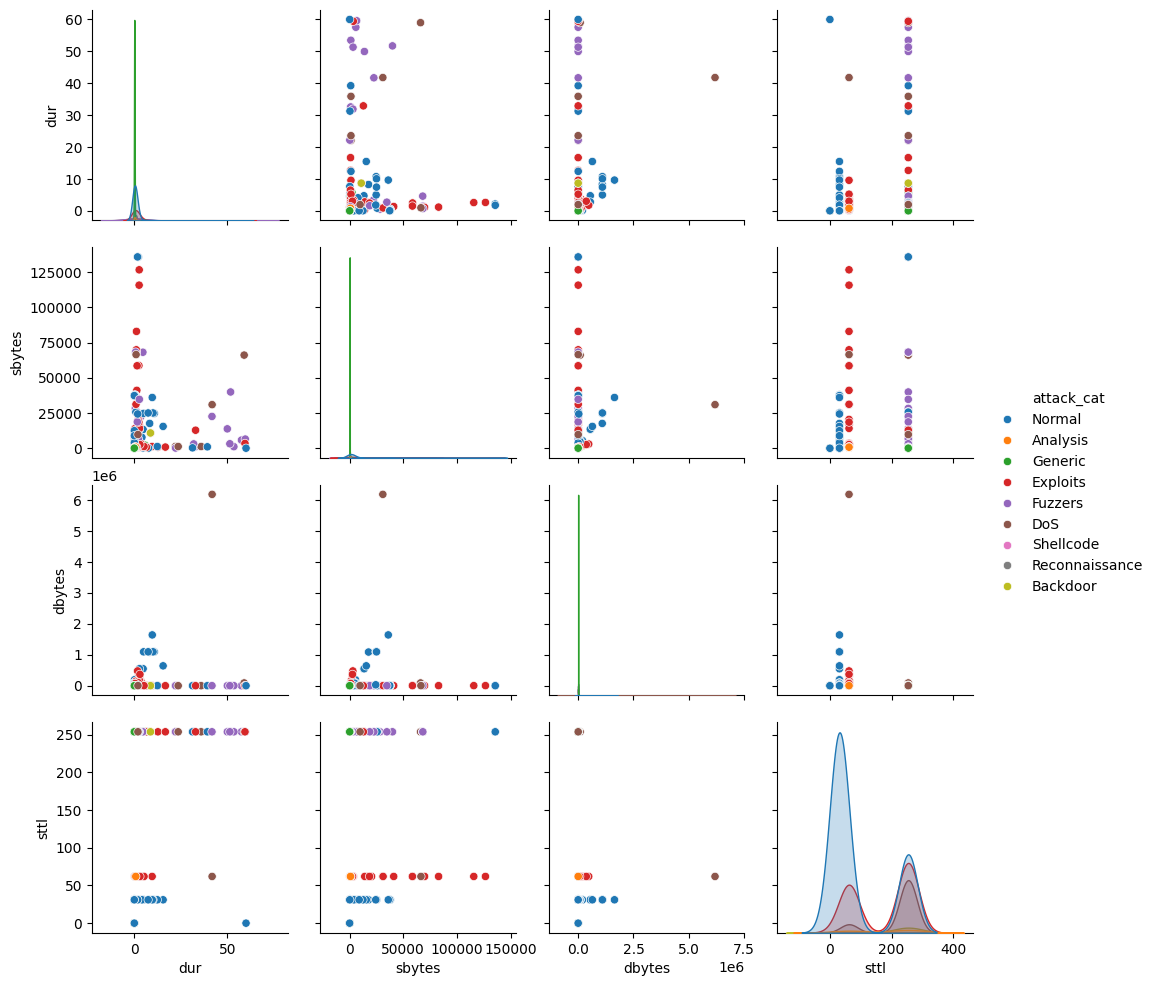

In [17]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(sample_df[["dur", "sbytes", "dbytes", "sttl", "attack_cat"]], hue="attack_cat")
plt.show()

Drop Unnecessary Columns

**Fix:** also drop `label` here. `label` is just a binarized version of `attack_cat` (0 = Normal, 1 = any attack), so leaving it in `X` while predicting `attack_cat` is target leakage — it lets the models trivially separate Normal vs. Attack and inflates every accuracy score.

In [18]:
df.drop(["id","label"],axis=1,inplace=True)

Encode Categorical feature

In [19]:
categorical_cols= df.select_dtypes(include="object").columns
encoders={}

for col in categorical_cols:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col].astype(str))
  encoders[col]=le

print("Encoding Complete")

Encoding Complete


Feature

In [20]:
X = df.drop("attack_cat",axis=1)

y = df["attack_cat"]

Train Test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

Random Forest Model

In [22]:
rf=RandomForestClassifier(
    n_estimators=200,
   # max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_acc=accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:",rf_acc)

Random Forest Accuracy: 0.8283884738527214


Decision Tree

In [23]:
dt=DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

dt_acc=accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",dt_acc)

Decision Tree Accuracy: 0.808673716891433


Logistic Regression

In [24]:
from sklearn.preprocessing import StandardScaler

# Fix: Logistic Regression is distance/gradient based, so unscaled
# features (e.g. sbytes/dbytes in the thousands vs. 0/1 flags) slow
# convergence and bias the coefficients. Scale only for this model.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr=LogisticRegression( max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled,y_train)

lr_pred=lr.predict(X_test_scaled)

lr_acc=accuracy_score(y_test,lr_pred)
print("Logistic Regression Accuracy:",lr_acc)

Logistic Regression Accuracy: 0.7594450373532551


Naive Bayes

In [25]:
nb=GaussianNB()

nb.fit(X_train,y_train)

nb_pred=nb.predict(X_test)

nb_acc=accuracy_score(y_test,nb_pred)
print("Naive Bayes Accuracy:",nb_acc)

Naive Bayes Accuracy: 0.4386339381003202


XGBoost

In [26]:
xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=len(np.unique(y)),

    n_estimators=200,

    max_depth=6,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss"

)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy =", xgb_acc)

XGBoost Accuracy = 0.8319976714853983


Accuracy Comparison

In [27]:
result=pd.DataFrame({
    "Model":["Random Forest","Decision Tree","Logistic Regression","Naive Bayes","XGBoost"],
    "Accuracy":[rf_acc,dt_acc,lr_acc,nb_acc,xgb_acc]
})

result.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
4,XGBoost,0.831998
0,Random Forest,0.828388
1,Decision Tree,0.808674
2,Logistic Regression,0.759445
3,Naive Bayes,0.438634


Accuracy Graph

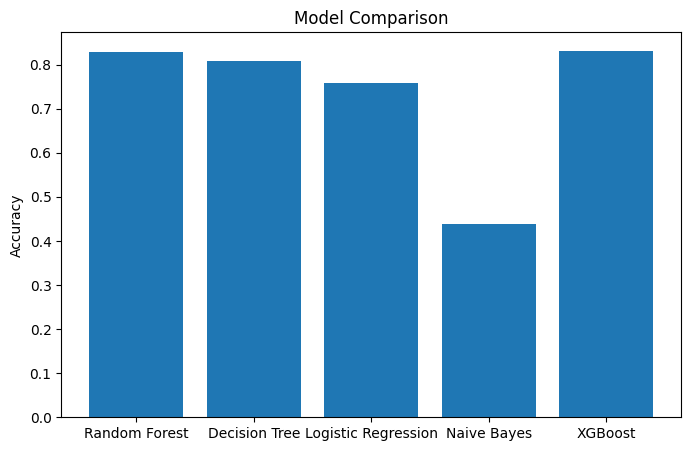

In [28]:
plt.figure(figsize=(8,5))

plt.bar(result["Model"],result["Accuracy"])

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

Classification Report

In [29]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.14      0.24       535
           1       0.86      0.11      0.19       466
           2       0.33      0.24      0.27      3271
           3       0.64      0.82      0.72      8905
           4       0.70      0.61      0.65      4849
           5       1.00      0.98      0.99     11774
           6       0.92      0.95      0.93     18600
           7       0.93      0.77      0.84      2798
           8       0.62      0.64      0.63       302
           9       0.58      0.31      0.41        35

    accuracy                           0.83     51535
   macro avg       0.75      0.56      0.59     51535
weighted avg       0.83      0.83      0.82     51535



In [30]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.49      0.15      0.23       535
           1       0.62      0.12      0.20       466
           2       0.32      0.31      0.31      3271
           3       0.64      0.75      0.69      8905
           4       0.63      0.60      0.62      4849
           5       0.99      0.98      0.99     11774
           6       0.92      0.91      0.92     18600
           7       0.89      0.76      0.82      2798
           8       0.57      0.61      0.59       302
           9       0.53      0.51      0.52        35

    accuracy                           0.81     51535
   macro avg       0.66      0.57      0.59     51535
weighted avg       0.81      0.81      0.81     51535



In [31]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.62      0.03      0.06       535
           1       0.00      0.00      0.00       466
           2       0.33      0.05      0.09      3271
           3       0.56      0.81      0.66      8905
           4       0.55      0.39      0.46      4849
           5       0.98      0.97      0.98     11774
           6       0.86      0.89      0.87     18600
           7       0.52      0.66      0.58      2798
           8       0.60      0.01      0.02       302
           9       0.50      0.03      0.05        35

    accuracy                           0.76     51535
   macro avg       0.55      0.38      0.38     51535
weighted avg       0.74      0.76      0.73     51535



In [32]:
print(classification_report(y_test,nb_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       535
           1       0.00      0.00      0.00       466
           2       0.10      0.00      0.00      3271
           3       0.63      0.02      0.04      8905
           4       0.25      0.27      0.26      4849
           5       0.48      0.98      0.64     11774
           6       0.90      0.46      0.61     18600
           7       0.08      0.36      0.14      2798
           8       0.01      0.01      0.01       302
           9       0.04      0.11      0.05        35

    accuracy                           0.44     51535
   macro avg       0.25      0.22      0.18     51535
weighted avg       0.58      0.44      0.41     51535



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.93      0.12      0.21       535
           1       0.93      0.12      0.21       466
           2       0.48      0.13      0.20      3271
           3       0.63      0.90      0.74      8905
           4       0.70      0.56      0.62      4849
           5       1.00      0.98      0.99     11774
           6       0.90      0.95      0.92     18600
           7       0.92      0.78      0.84      2798
           8       0.64      0.69      0.66       302
           9       0.58      0.54      0.56        35

    accuracy                           0.83     51535
   macro avg       0.77      0.58      0.60     51535
weighted avg       0.83      0.83      0.81     51535



Confusion Matrix

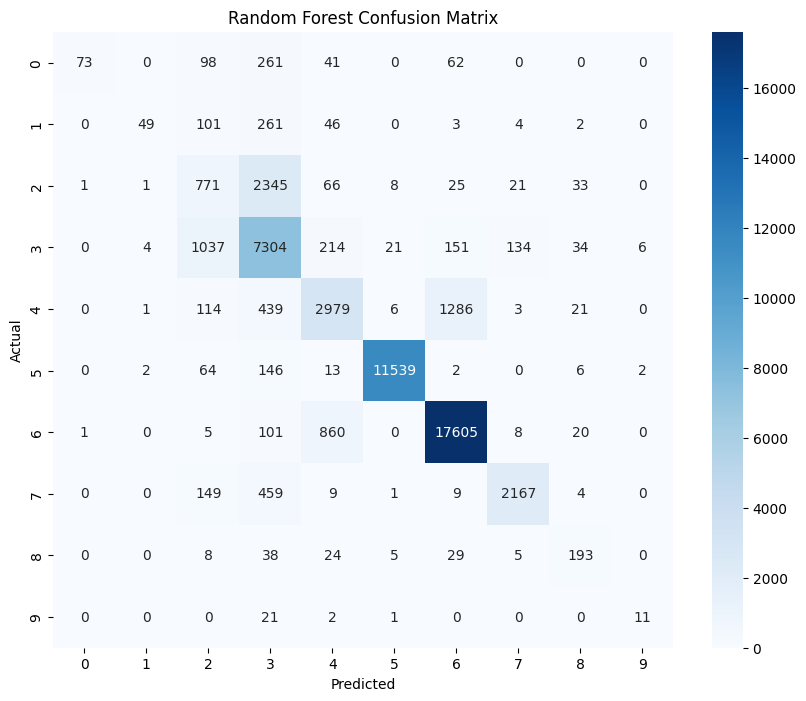

In [34]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

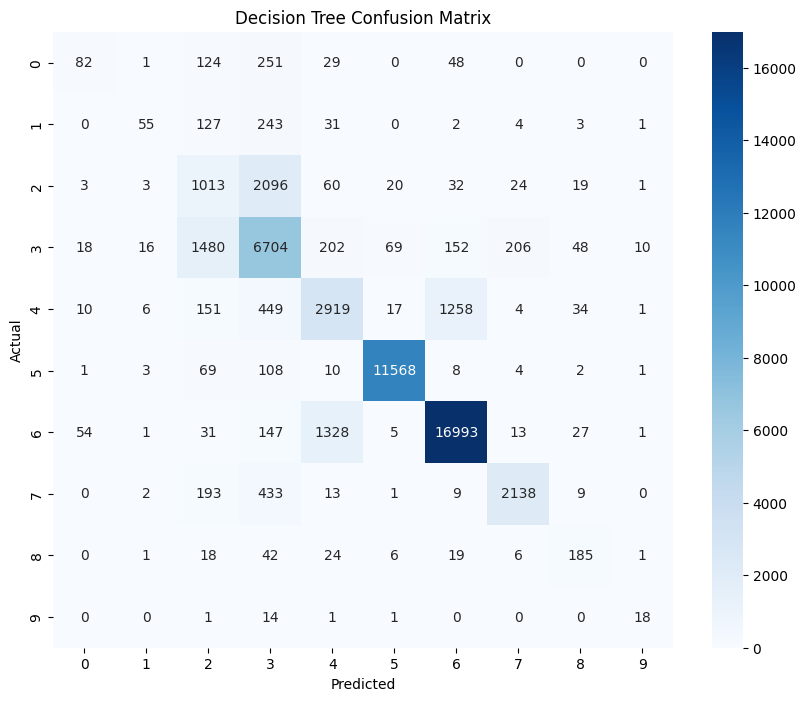

In [35]:
cm = confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

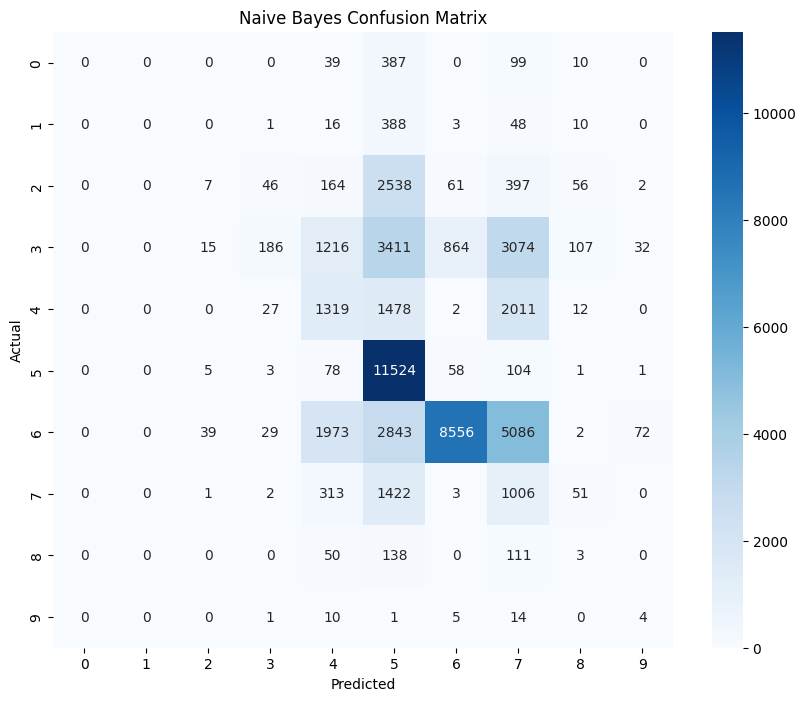

In [36]:
cm = confusion_matrix(y_test,nb_pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

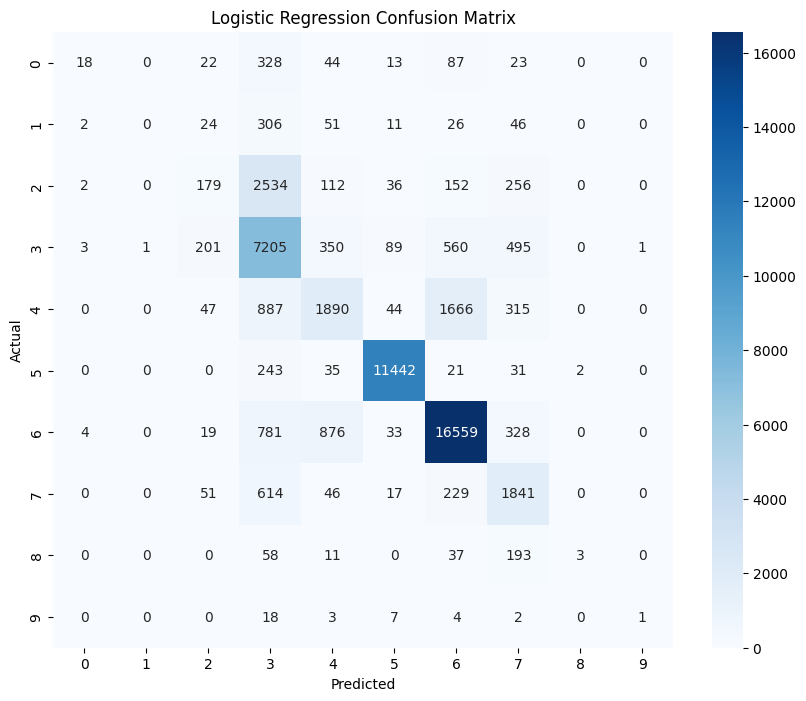

In [37]:
cm = confusion_matrix(y_test,lr_pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

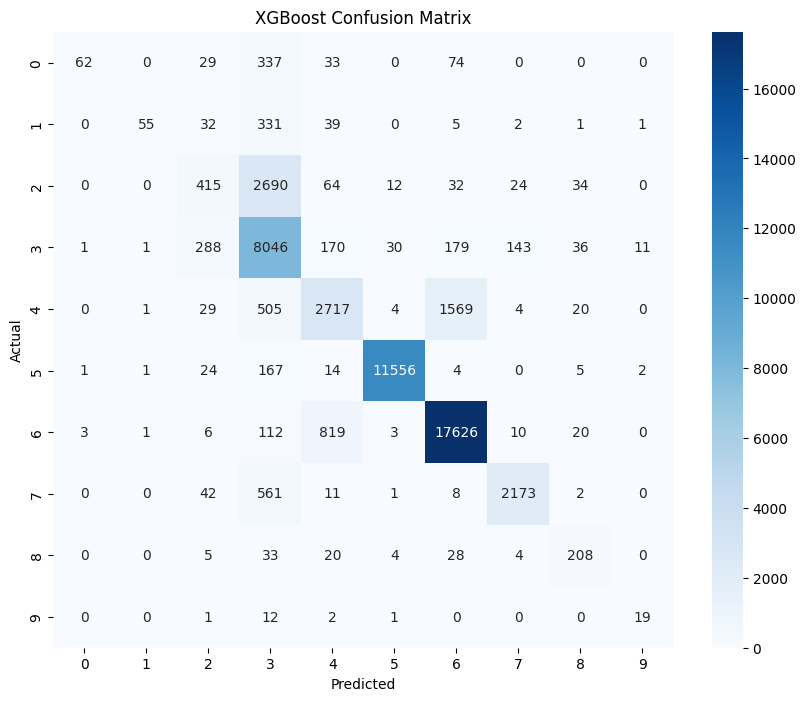

In [38]:
cm = confusion_matrix(y_test,xgb_pred)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

Feature Importance

In [39]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance=importance.sort_values(by="Importance",ascending=False)

importance.head(15)

,Feature,Importance
6,sbytes,0.092268
26,smean,0.063548
9,sttl,0.061811
33,ct_src_dport_ltm,0.059524
40,ct_srv_dst,0.056457
34,ct_dst_sport_ltm,0.054112
35,ct_dst_src_ltm,0.052580
30,ct_srv_src,0.045435
11,sload,0.040088
2,service,0.039427


Top Features

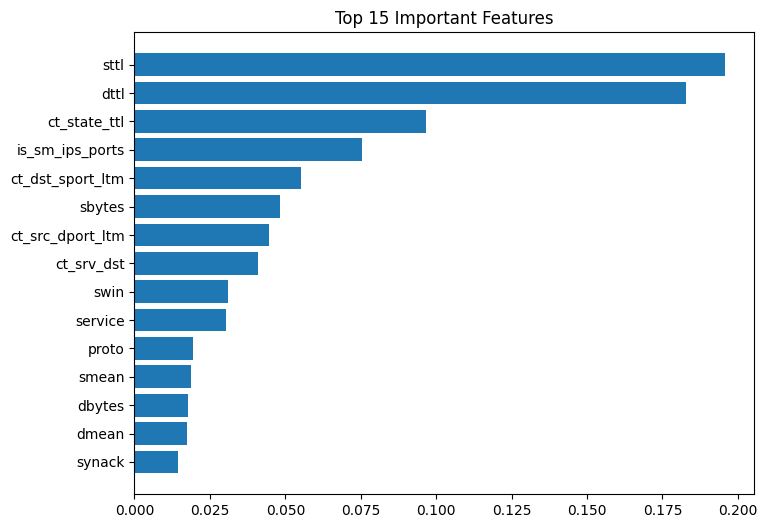

In [41]:
plt.figure(figsize=(8,6))

plt.barh(

    importance["Feature"][:15],

    importance["Importance"][:15]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

ROC Curve

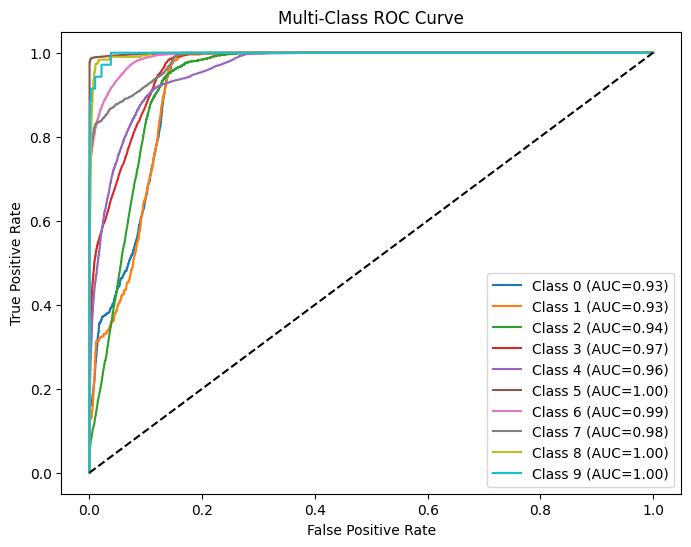

In [42]:
classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

y_score = xgb.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(

        y_test_bin[:, i],

        y_score[:, i]

    )

    roc_auc = auc(fpr, tpr)

    plt.plot(

        fpr,

        tpr,

        label=f"Class {i} (AUC={roc_auc:.2f})"

    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend()

plt.show()

Precision-Recall Curve

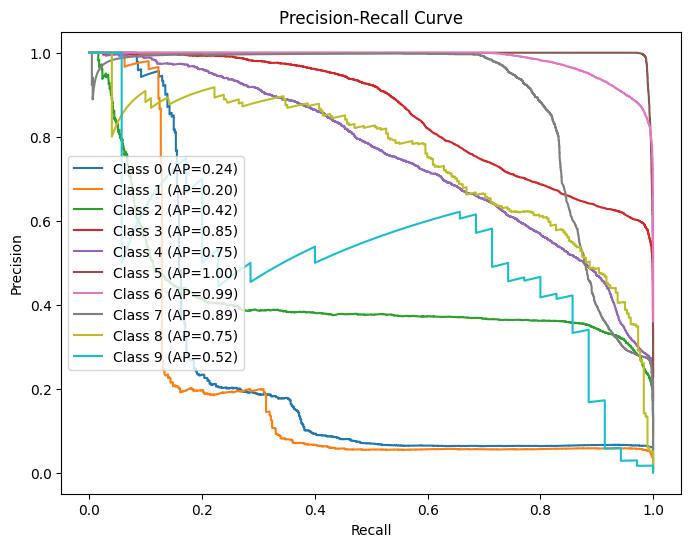

In [43]:
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    precision, recall, _ = precision_recall_curve(

        y_test_bin[:, i],

        y_score[:, i]

    )

    ap = average_precision_score(

        y_test_bin[:, i],

        y_score[:, i]

    )

    plt.plot(

        recall,

        precision,

        label=f"Class {i} (AP={ap:.2f})"

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()